**Instalasi Library**

In [1]:
!pip install mlxtend openpyxl streamlit plotly

  Using cached blinker-1.9.0-py3-none-any.whl.metadata (1.6 kB)
  Using cached toml-0.10.2-py2.py3-none-any.whl.metadata (7.1 kB)
  Using cached watchdog-6.0.0-py3-none-win_amd64.whl.metadata (44 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached gitdb-4.0.12-py3-none-any.whl.metadata (1.2 kB)
  Using cached jsonschema_specifications-2025.9.1-py3-none-any.whl.metadata (2.9 kB)
  Using cached referencing-0.37.0-py3-none-any.whl.metadata (2.8 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
   ------------------------------ --------- 1.0/1.4 MB 2.5 MB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 2.7 MB/s  0:00:00
   ---------------------------------------- 0.0/9.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.1 MB 4.2 MB/s eta 0:00:03
   ----- ---------------

In [4]:
!pip install seaborn matplotlib pandas

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


**Import Library**

In [5]:
import pandas as pd
import numpy as np
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

print("Semua library berhasil diimport.")

Semua library berhasil diimport.


**Load Dataset**

In [10]:
df = pd.read_excel(
    'Online_Retail_Dataset.xlsx',  # Path relatif dari folder project
    dtype={'CustomerID': str, 'InvoiceNo': str}  # Paksa tipe str agar tidak kehilangan leading zero
)

print(f" Shape awal dataset : {df.shape}")
print(f"\n 5 baris pertama:")
df.head()

 Shape awal dataset : (541909, 8)

 5 baris pertama:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


**EDA**

In [11]:
print("=" * 50)
print("INFORMASI DATASET")
print("=" * 50)
df.info()

print("\n" + "=" * 50)
print("JUMLAH NILAI KOSONG (NULL) PER KOLOM")
print("=" * 50)
print(df.isnull().sum())

print("\n" + "=" * 50)
print("STATISTIK DESKRIPTIF")
print("=" * 50)
print(df.describe())

print("\n" + "=" * 50)
print(f"Jumlah negara unik  : {df['Country'].nunique()}")
print(f"Jumlah invoice unik : {df['InvoiceNo'].nunique()}")
print(f"Jumlah produk unik  : {df['Description'].nunique()}")

INFORMASI DATASET
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  str           
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  str           
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(1), object(2), str(3)
memory usage: 45.1+ MB

JUMLAH NILAI KOSONG (NULL) PER KOLOM
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

STATISTIK DESKRIPTIF
            Quantity                 Invoice

**Data Cleaning**

In [12]:
df_clean = df.copy()

# ── LANGKAH 1: Hapus baris dengan 'Description' atau 'CustomerID' kosong ──
# Description kosong berarti kita tidak tahu produk apa yang dibeli.
# CustomerID kosong berarti transaksi tidak dapat ditelusuri.
before = len(df_clean)
df_clean.dropna(subset=['Description', 'CustomerID'], inplace=True)
after = len(df_clean)
print(f"[1] Hapus null Description/CustomerID : {before - after} baris dihapus")

# ── LANGKAH 2: Hapus transaksi yang dibatalkan ──
# InvoiceNo yang diawali 'C' (contoh: C536379) adalah transaksi retur/cancel.
# Ini bukan pola pembelian nyata, sehingga harus dibuang.
before = len(df_clean)
df_clean = df_clean[~df_clean['InvoiceNo'].str.startswith('C')]
after = len(df_clean)
print(f"[2] Hapus transaksi cancel (awalan 'C'): {before - after} baris dihapus")

# ── LANGKAH 3: Hapus Quantity dan UnitPrice yang negatif atau nol ──
# Nilai negatif biasanya muncul karena penyesuaian manual atau retur.
# Nilai nol bisa berarti sample gratis yang tidak relevan.
before = len(df_clean)
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]
after = len(df_clean)
print(f"[3] Hapus Quantity/UnitPrice <= 0     : {before - after} baris dihapus")

# ── LANGKAH 4: Bersihkan teks Description ──
# strip()  → hapus spasi di awal dan akhir
# upper()  → seragamkan kapital agar 'APPLE' dan 'apple' dianggap sama
df_clean['Description'] = df_clean['Description'].str.strip().str.upper()

# ── LANGKAH 5: Reset index ──
df_clean.reset_index(drop=True, inplace=True)

print("\n" + "=" * 50)
print(f"✅ Data bersih   : {df_clean.shape[0]} baris, {df_clean.shape[1]} kolom")
print(f"   (dari semula  : {df.shape[0]} baris)")
print("=" * 50)

df_clean.head()

[1] Hapus null Description/CustomerID : 135080 baris dihapus
[2] Hapus transaksi cancel (awalan 'C'): 8905 baris dihapus
[3] Hapus Quantity/UnitPrice <= 0     : 40 baris dihapus

✅ Data bersih   : 397884 baris, 8 kolom
   (dari semula  : 541909 baris)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


**Country Distribution**

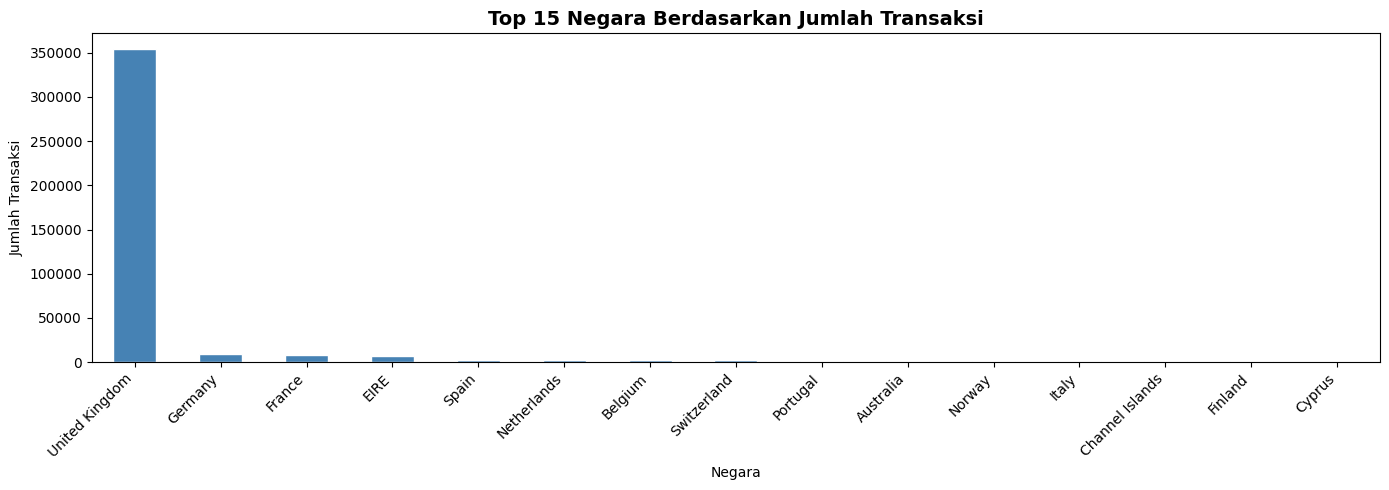


Top 5 negara:
Country
United Kingdom    354321
Germany             9040
France              8341
EIRE                7236
Spain               2484
Name: count, dtype: int64


In [13]:
# =============================================================
# VISUALISASI DISTRIBUSI NEGARA
# Berguna untuk memilih negara yang datanya cukup banyak
# agar analisis apriori menghasilkan aturan yang bermakna.
# =============================================================

country_counts = df_clean['Country'].value_counts()

plt.figure(figsize=(14, 5))
country_counts.head(15).plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Top 15 Negara Berdasarkan Jumlah Transaksi', fontsize=14, fontweight='bold')
plt.xlabel('Negara')
plt.ylabel('Jumlah Transaksi')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('country_distribution.png', dpi=150)
plt.show()

print(f"\nTop 5 negara:")
print(country_counts.head())

**Data Transformation (One-Hot Encoding)**

In [15]:
# =============================================================
# DATA TRANSFORMATION — One-Hot Encoding (OHE)
#
# Format yang dibutuhkan Apriori adalah "basket matrix":
#   - Setiap BARIS  = satu transaksi/invoice
#   - Setiap KOLOM  = satu produk (Description)
#   - Nilai         = True/False (apakah produk ada dalam transaksi?)
#
# Contoh output:
#   InvoiceNo | APPLE | BREAD | MILK
#   536365    | True  | False | True
#   536366    | False | True  | True
# =============================================================

def create_basket(dataframe, country=None):
    """
    Membuat basket matrix (One-Hot Encoded) dari dataframe.
    
    Parameter:
    ----------
    dataframe : pd.DataFrame — Data yang sudah dibersihkan
    country   : str atau None — Filter berdasarkan negara. None = semua negara.
    
    Returns:
    --------
    basket_encoded : pd.DataFrame — Matrix OHE siap pakai untuk Apriori
    """
    # Filter berdasarkan negara jika diminta
    if country and country != 'All Countries':
        dataframe = dataframe[dataframe['Country'] == country]
    
    # Buat pivot table: baris=InvoiceNo, kolom=Description, nilai=sum(Quantity)
    # Kita gunakan sum karena satu invoice bisa membeli produk yang sama lebih dari sekali
    basket = (
        dataframe
        .groupby(['InvoiceNo', 'Description'])['Quantity']
        .sum()
        .unstack()          # Ubah Description menjadi kolom
        .reset_index()      # Kembalikan InvoiceNo sebagai kolom biasa
        .fillna(0)          # Isi NaN (produk yang tidak dibeli) dengan 0
        .set_index('InvoiceNo')  # Set InvoiceNo kembali sebagai index
    )
    
    # Konversi angka ke boolean: > 0 → True, = 0 → False
    # Ini yang disebut One-Hot Encoding untuk basket analysis
    basket_encoded = basket.map(lambda x: True if x > 0 else False)
    
    return basket_encoded


# ── Contoh: Buat basket untuk United Kingdom (negara dengan data terbanyak) ──
basket_uk = create_basket(df_clean, country='United Kingdom')

print(f" Ukuran basket matrix (UK) : {basket_uk.shape}")
print(f"   → {basket_uk.shape[0]} invoice  x  {basket_uk.shape[1]} produk unik")
print(f"\n5 baris pertama (5 kolom pertama):")
basket_uk.iloc[:5, :5]

 Ukuran basket matrix (UK) : (16646, 3833)
   → 16646 invoice  x  3833 produk unik

5 baris pertama (5 kolom pertama):


Description,10 COLOUR SPACEBOY PEN,12 COLOURED PARTY BALLOONS,12 DAISY PEGS IN WOOD BOX,12 EGG HOUSE PAINTED WOOD,12 HANGING EGGS HAND PAINTED
InvoiceNo,,,,,
536365,False,False,False,False,False
536366,False,False,False,False,False
536367,False,False,False,False,False
536368,False,False,False,False,False
536369,False,False,False,False,False


**Algoritma Apriori**

In [16]:
# =============================================================
# ALGORITMA APRIORI — Mencari Frequent Itemsets
#
# min_support = batas minimum seberapa sering itemset muncul.
# Rumus support: support(A) = transaksi_mengandung_A / total_transaksi
#
# Contoh: min_support=0.02 artinya itemset harus muncul minimal
# di 2% dari total transaksi agar dianggap "frequent".
#
# use_colnames=True agar output menggunakan nama produk,
# bukan indeks kolom.
# =============================================================

MIN_SUPPORT = 0.02   # Sesuaikan dengan kebutuhan (range: 0.01 - 0.1)

frequent_itemsets = apriori(
    basket_uk,
    min_support=MIN_SUPPORT,
    use_colnames=True,     # Tampilkan nama produk, bukan nomor kolom
    max_len=4              # Batasi maksimal 4 item per itemset (efisiensi)
)

# Tambahkan kolom panjang itemset untuk memudahkan filter
frequent_itemsets['itemset_length'] = frequent_itemsets['itemsets'].apply(len)

print(f"✅ Total frequent itemsets ditemukan : {len(frequent_itemsets)}")
print(f"\nDistribusi panjang itemset:")
print(frequent_itemsets['itemset_length'].value_counts().sort_index())
print(f"\n10 itemset dengan support tertinggi:")
frequent_itemsets.sort_values('support', ascending=False).head(10)

✅ Total frequent itemsets ditemukan : 236

Distribusi panjang itemset:
itemset_length
1    200
2     35
3      1
Name: count, dtype: int64

10 itemset dengan support tertinggi:


,support,itemsets,itemset_length
185,0.113180,frozenset({WHITE HANGING HEART T-LIGHT HOLDER}),1
79,0.086928,frozenset({JUMBO BAG RED RETROSPOT}),1
149,0.084705,frozenset({REGENCY CAKESTAND 3 TIER}),1
11,0.078097,frozenset({ASSORTED COLOUR BIRD ORNAMENT}),1
123,0.077496,frozenset({PARTY BUNTING}),1
101,0.067283,frozenset({LUNCH BAG RED RETROSPOT}),1
160,0.060495,frozenset({SET OF 3 CAKE TINS PANTRY DESIGN}),1
94,0.059834,frozenset({LUNCH BAG BLACK SKULL.}),1
119,0.056770,frozenset({PAPER CHAIN KIT 50'S CHRISTMAS}),1
108,0.056350,frozenset({NATURAL SLATE HEART CHALKBOARD}),1


**Generate Association Rules**

In [17]:
# =============================================================
# ASSOCIATION RULES — Menghasilkan Aturan Asosiasi
#
# Dari frequent itemsets, kita hasilkan aturan berbentuk:
#   "Jika membeli A → kemungkinan besar membeli B"
#
# digunakan 'lift' sebagai metric utama karena:
# - Lebih informatif dari confidence saja
# - Lift > 1 membuktikan A dan B saling berkaitan
# =============================================================

MIN_CONFIDENCE = 0.3   # Minimal 30% kemungkinan pembelian bersama

rules = association_rules(
    frequent_itemsets,
    metric='lift',
    min_threshold=1.0      # Hanya aturan dengan lift > 1 (hubungan positif)
)

# Filter tambahan berdasarkan confidence
rules = rules[rules['confidence'] >= MIN_CONFIDENCE]

# Urutkan berdasarkan lift tertinggi (aturan terkuat)
rules = rules.sort_values('lift', ascending=False).reset_index(drop=True)

# Konversi frozenset ke string agar lebih mudah dibaca
rules['antecedents_str'] = rules['antecedents'].apply(lambda x: ', '.join(list(x)))
rules['consequents_str'] = rules['consequents'].apply(lambda x: ', '.join(list(x)))

print(f"✅ Total aturan asosiasi ditemukan : {len(rules)}")
print(f"\n10 aturan dengan Lift tertinggi:")
rules[['antecedents_str', 'consequents_str', 'support', 'confidence', 'lift']].head(10)

✅ Total aturan asosiasi ditemukan : 67

10 aturan dengan Lift tertinggi:


,antecedents_str,consequents_str,support,confidence,lift
0,"PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY ...",GREEN REGENCY TEACUP AND SAUCER,0.020485,0.890339,24.216650
1,GREEN REGENCY TEACUP AND SAUCER,"PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY ...",0.020485,0.557190,24.216650
2,PINK REGENCY TEACUP AND SAUCER,"GREEN REGENCY TEACUP AND SAUCER, ROSES REGENCY...",0.020485,0.691684,24.188581
3,"GREEN REGENCY TEACUP AND SAUCER, ROSES REGENCY...",PINK REGENCY TEACUP AND SAUCER,0.020485,0.716387,24.188581
4,GREEN REGENCY TEACUP AND SAUCER,PINK REGENCY TEACUP AND SAUCER,0.024270,0.660131,22.289120
5,PINK REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,0.024270,0.819473,22.289120
6,"GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY ...",ROSES REGENCY TEACUP AND SAUCER,0.020485,0.844059,20.723028
7,ROSES REGENCY TEACUP AND SAUCER,"GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY ...",0.020485,0.502950,20.723028
8,GREEN REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,0.028595,0.777778,19.095706
9,ROSES REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,0.028595,0.702065,19.095706


**Visualisasi Hasil**

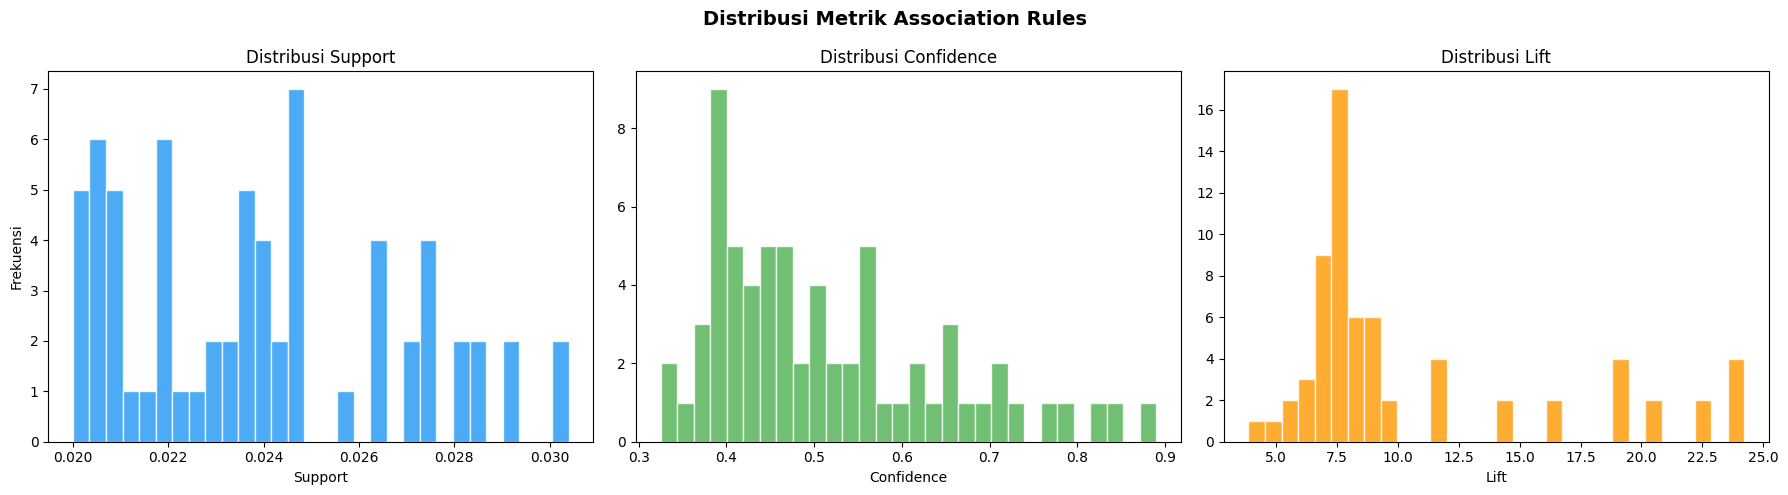

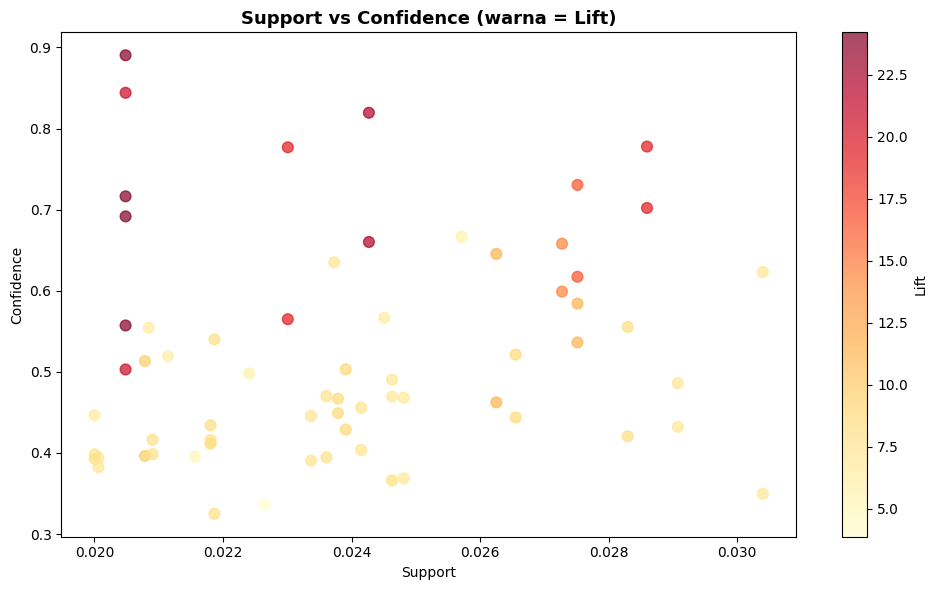

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribusi Metrik Association Rules', fontsize=14, fontweight='bold')

# ── Plot 1: Support ──
axes[0].hist(rules['support'], bins=30, color='#2196F3', edgecolor='white', alpha=0.8)
axes[0].set_title('Distribusi Support')
axes[0].set_xlabel('Support')
axes[0].set_ylabel('Frekuensi')

# ── Plot 2: Confidence ──
axes[1].hist(rules['confidence'], bins=30, color='#4CAF50', edgecolor='white', alpha=0.8)
axes[1].set_title('Distribusi Confidence')
axes[1].set_xlabel('Confidence')

# ── Plot 3: Lift ──
axes[2].hist(rules['lift'], bins=30, color='#FF9800', edgecolor='white', alpha=0.8)
axes[2].set_title('Distribusi Lift')
axes[2].set_xlabel('Lift')

plt.tight_layout()
plt.savefig('metrics_distribution.png', dpi=150)
plt.show()

# ── Scatter Plot: Support vs Confidence (diwarnai oleh Lift) ──
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    rules['support'],
    rules['confidence'],
    c=rules['lift'],
    cmap='YlOrRd',
    alpha=0.7,
    s=60
)
plt.colorbar(scatter, label='Lift')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.title('Support vs Confidence (warna = Lift)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('scatter_support_confidence.png', dpi=150)
plt.show()